In [1]:
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv


In [2]:
load_dotenv()

True

In [3]:
engine=create_engine(f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}")
df=pd.read_sql("Select *FROM gold_sales_data",con=engine)

In [4]:
df["Date"]=pd.to_datetime(df["Date"])

In [5]:
df=df.sort_values(['Store','Dept','Date'])
df['lag_1']=df.groupby(['Store',"Dept"])["Weekly_Sales"].shift(1)
df['lag_2']=df.groupby(['Store',"Dept"])["Weekly_Sales"].shift(2)
df['lag_4']=df.groupby(['Store',"Dept"])["Weekly_Sales"].shift(4)
df[["lag_1","lag_2","lag_4"]]=df[["lag_1","lag_2","lag_4"]].fillna(0)

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score
features = ['Store', 'Dept', 'Size', 'IsHoliday', 'Temperature', 'Fuel_Price', 
            'CPI', 'Unemployment', 'Month', 'WeekOfYear', 'lag_1', 'lag_2', 'lag_4']
X = df[features]
y = df['Weekly_Sales']

In [7]:
split_point = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

In [8]:
rf_model=RandomForestRegressor(n_estimators=50,max_depth=15,n_jobs=-1,random_state=42)
rf_model.fit(X_train,y_train)

,n_estimators,50
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
y_pred=rf_model.predict(X_test)
print(f"MAE (Average Error): {mean_absolute_error(y_test, y_pred)}")
print(f"Accuracy Score (R2): {r2_score(y_test, y_pred)}")

MAE (Average Error): 1288.9392254356862
Accuracy Score (R2): 0.9451657057370643


In [14]:
import shap

# 1. SHAP Explainer banayein (Random Forest ke liye TreeExplainer best hai)
# Hum X_test ka ek chota hissa lete hain taake process jaldi ho
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test.iloc[:1000])

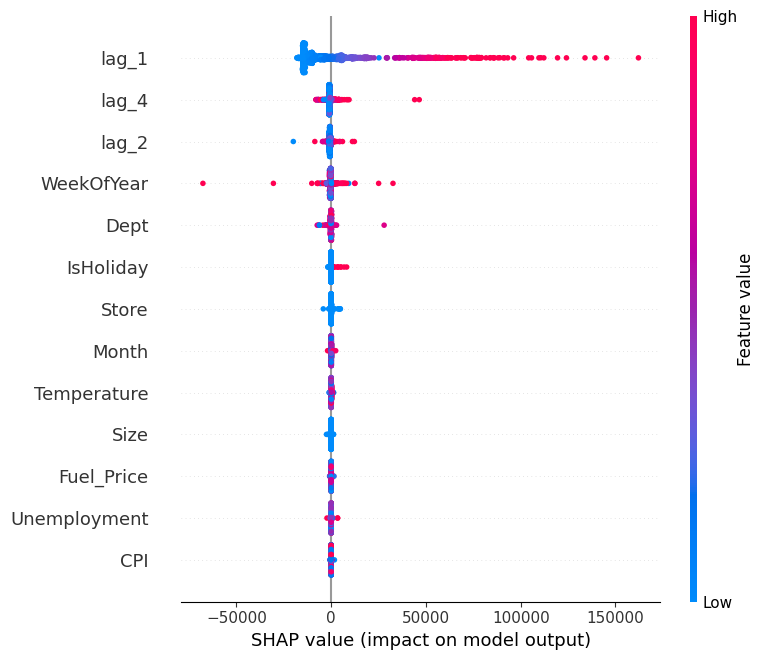

In [15]:
# 2. Summary Plot (Ye dikhayega top features kaunse hain)
shap.summary_plot(shap_values, X_test.iloc[:1000])

In [16]:
import joblib
joblib.dump(rf_model,"walmart_rf_model.pkl")
joblib.dump(features,"features.pkl")

['features.pkl']